<a href="https://colab.research.google.com/github/pavanKarthik2006/Genomic-Phylogenetic-Reconstruction-of-SARS-CoV-2-Strains-An-Automated-Computational-Pipeline/blob/main/Copy_of_Phylogenetic_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

# This will open a button for you to browse your local computer
uploaded = files.upload()

# Once uploaded, your file will be in the current Colab directory
# You can check by listing the files:
!ls

Saving aligned_sequences.fasta.iqtree to aligned_sequences.fasta.iqtree
Saving aligned_sequences.fasta.mldist to aligned_sequences.fasta.mldist
Saving aligned_sequences.fasta.treefile to aligned_sequences.fasta.treefile
aligned_sequences.fasta.iqtree	aligned_sequences.fasta.treefile
aligned_sequences.fasta.mldist	sample_data


In [ ]:
!pip install Bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.3/321.3 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.7 MB/s eta 0:00:00


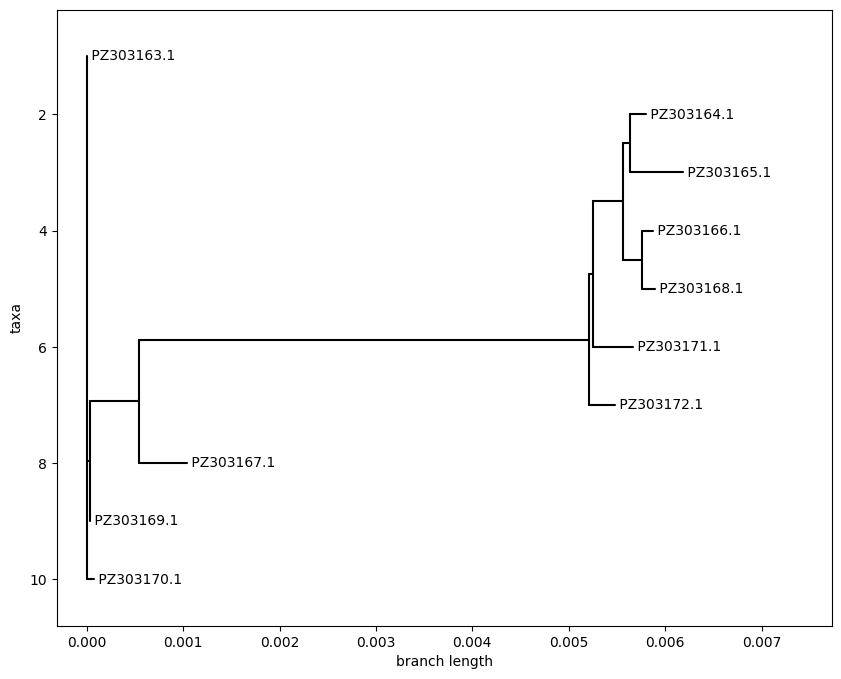

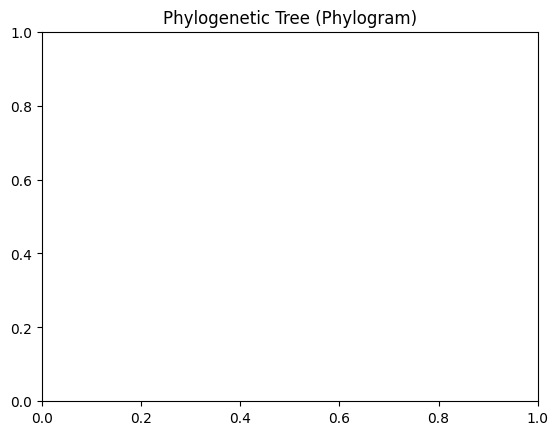

In [ ]:
from Bio import Phylo
import matplotlib.pyplot as plt

tree = Phylo.read("aligned_sequences.fasta.treefile", "newick")

# Create a figure
fig, ax = plt.subplots(figsize=(10, 8))
# 'branch_labels' shows distance if available
Phylo.draw(tree, axes=ax, branch_labels=None)
plt.title("Phylogenetic Tree (Phylogram)")
plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4943/2916010176.py:6: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("aligned_sequences.fasta.mldist", sep="\s+", skiprows=1, header=None)


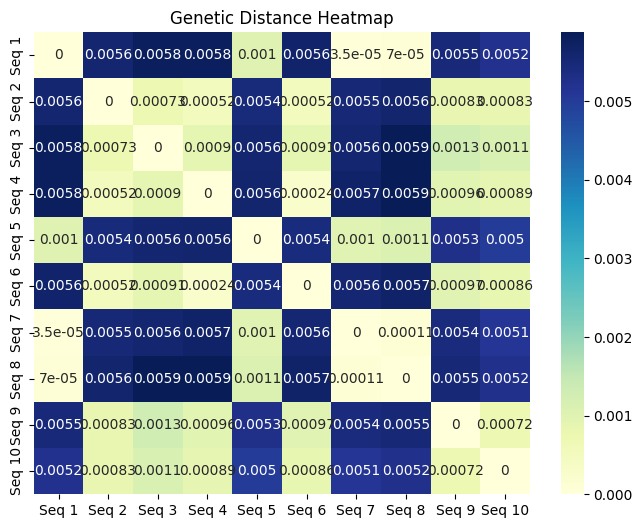

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load distance matrix (skipping the first line which is just the sequence count)
df = pd.read_csv("aligned_sequences.fasta.mldist", sep="\s+", skiprows=1, header=None)

# The matrix values start from column 1
matrix = df.iloc[:, 1:]
labels = [f"Seq {i+1}" for i in range(len(matrix))] # Or use headers if available

plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, cmap="YlGnBu", xticklabels=labels, yticklabels=labels)
plt.title("Genetic Distance Heatmap")
plt.show()

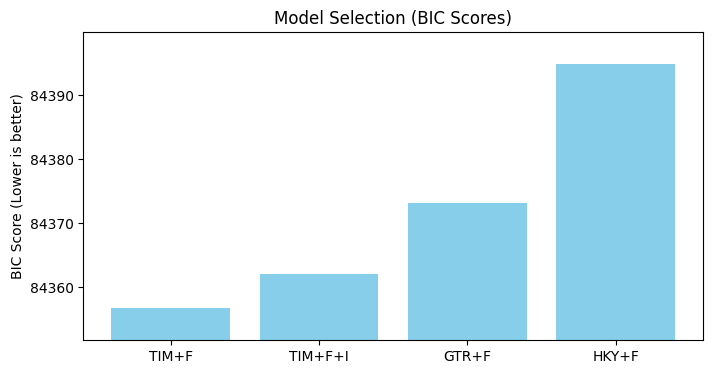

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Extracting the BIC scores from the iqtree file (simulated extraction)
# You would manually copy the model and BIC column from your .iqtree file to a CSV or dataframe
data = {
    'Model': ['TIM+F', 'TIM+F+I', 'GTR+F', 'HKY+F'],
    'BIC': [84356.7, 84362.0, 84373.1, 84394.8]
}
df_models = pd.DataFrame(data).sort_values('BIC')

plt.figure(figsize=(8, 4))
plt.bar(df_models['Model'], df_models['BIC'], color='skyblue')
plt.ylabel('BIC Score (Lower is better)')
plt.title('Model Selection (BIC Scores)')
plt.ylim(min(df_models['BIC'])-5, max(df_models['BIC'])+5)
plt.show()